# Machine Learning Final Project

## Chronic Kidney Disease Classification

**Course:** ISDS 7075E  
**Team Members:** Thais Diaz, Rhonda Swider, Cody Tatom


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### Import the data

In [2]:
df_kd = pd.read_excel("https://github.com/rcswider/Chronic-Kidney-Disease/blob/main/data/ML_project_kidney_disease.xlsx?raw=True")
df_kd_fields = pd.read_excel("https://github.com/rcswider/Chronic-Kidney-Disease/blob/main/data/ML_project_kidney_disease.xlsx?raw=True", sheet_name = "Fields")

## DATA EXPLORATION

# Preview the Dataset

In [3]:
df_kd.head(15)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,wc,rc,htn,dm,cad,appet,pe,ane,classification,CKD_class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,7800,5.2,yes,yes,no,good,no,no,ckd,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,6000,NaN,no,no,no,good,no,no,ckd,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,7500,NaN,no,yes,no,poor,no,yes,ckd,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,7300,4.6,no,no,no,good,no,no,ckd,1
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,7800,4.4,yes,yes,no,good,yes,no,ckd,1
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,NaN,NaN,no,no,no,good,no,no,ckd,1
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,6900,5,no,yes,no,good,yes,no,ckd,1
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,9600,4,yes,yes,no,good,no,yes,ckd,1
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,12100,3.7,yes,yes,no,poor,no,yes,ckd,1


# Explore the Dataset Structure

In [4]:
df_kd.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    object 
 18  r

# Sumary Statistics

In [5]:
df_kd.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,CKD_class
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.620000
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,0.485994
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,0.000000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,1.000000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


### Review the Data Dictionary

The second worksheet in the source file contains the field descriptions, expected data types, and coding information for the variables. This information was reviewed before cleaning so that numeric measurements, ordinal laboratory values, and categorical indicators could be handled appropriately.


In [6]:
df_kd_fields

,Name,Description,Type,value_info
0,age,age,Integer,age in years
1,bp,blood pressure,Integer,bp in mm/Hg
2,sg,specific gravity,Categorical,"1.005,1.010,1.015,1.020,1.025"
3,al,albumin,Categorical,"0,1,2,3,4,5"
4,su,sugar,Categorical,"0,1,2,3,4,5"
5,rbc,red blood cells,Binary,"normal,abnormal"
6,pc,pus cell,Binary,"normal,abnormal"
7,pcc,pus cell clumps,Binary,"present,notpresent"
8,ba,bacteria,Binary,"present,notpresent"
9,bgr,blood gluucose random,Integer,bgr in mgs/dl


# Identify Missing Values

In [7]:
df_kd.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
CKD_class           0
dtype: int64

Missing values were found in many of the columns. Since the dataset has only 400 records, deleting every row with a missing value would remove too much information. Numeric missing values were filled with either the mean or median, and categorical missing values were filled with the mode. This allowed all 400 records to remain in the analysis.


### Target Distribution

The frequency plot compares the two outcome classes before the data are divided for modeling. Of the 400 observations, 248 are classified as CKD and 152 as non-CKD. The outcome is therefore moderately imbalanced, with CKD accounting for 62% of the records. This imbalance is not extreme, but it supports the use of a stratified train/test split and evaluation measures beyond accuracy.


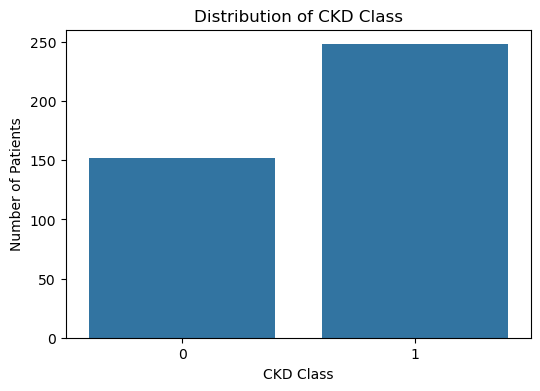

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='CKD_class', data=df_kd)

plt.title('Distribution of CKD Class')
plt.xlabel('CKD Class')
plt.ylabel('Number of Patients')

plt.show()

# Explore Numerical Variables

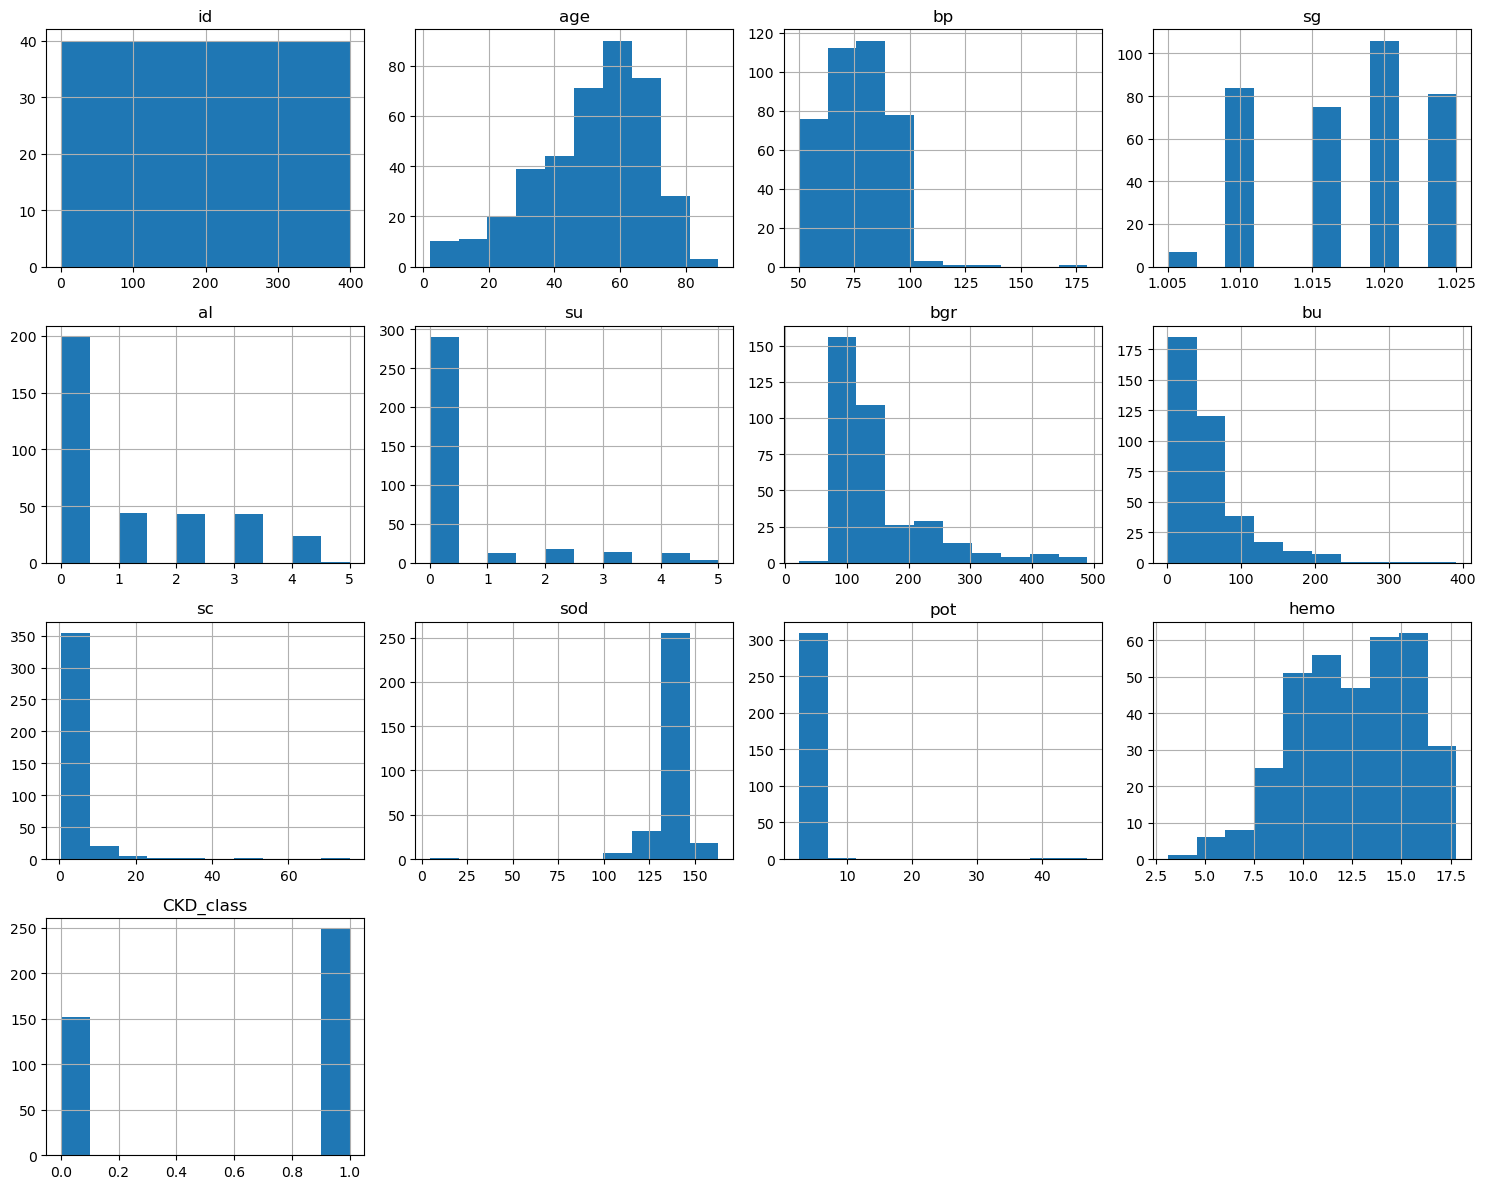

In [9]:
df_kd.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

### Distribution of Numerical Features

The histograms show how the numerical values are spread out. Blood glucose (`bgr`), blood urea (`bu`), and serum creatinine (`sc`) have several high values. Age and hemoglobin are more evenly spread. Specific gravity (`sg`), albumin (`al`), and sugar (`su`) have only a few possible values.

These differences are important because Logistic Regression works better when the predictors are on a similar scale. Scaling is included in its pipeline. Decision Trees and Random Forests do not require scaling because they use cutoff points to divide the data.


### Correlation Analysis

The correlation matrix was used to identify linear relationships among the numerical variables and to check for groups of predictors that may contain overlapping information. Correlation does not establish causation or guarantee predictive importance, but it provides a useful first look at multicollinearity and the structure of the laboratory measurements.


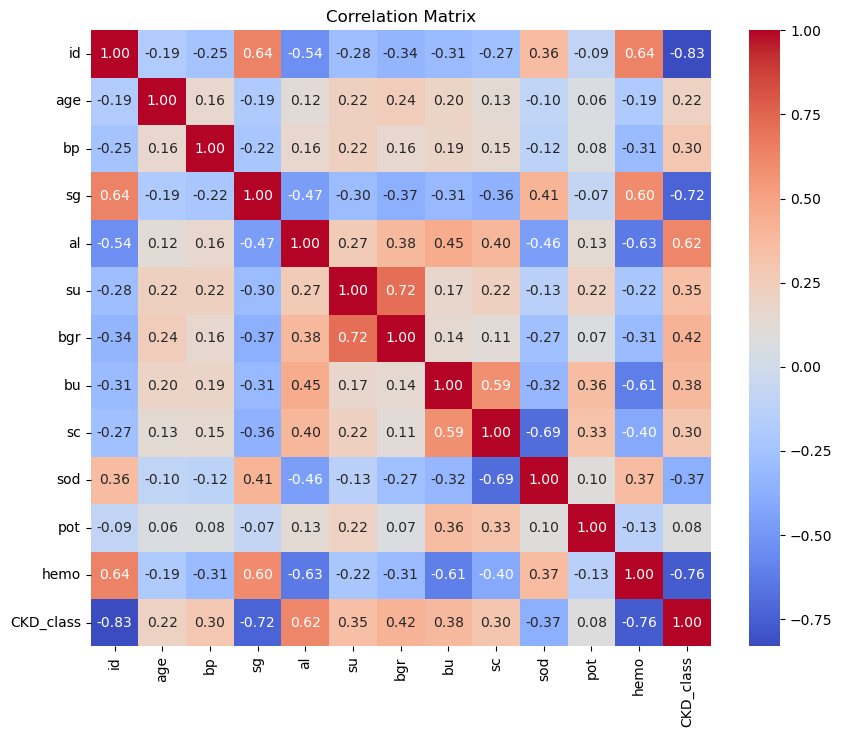

In [10]:
plt.figure(figsize=(10,8))

correlation = df_kd.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

Hemoglobin (`hemo`), packed cell volume (`pcv`), and red blood cell count (`rc`) are closely related. Hemoglobin and packed cell volume have a correlation of 0.85. Packed cell volume and red blood cell count have a correlation of 0.70, while hemoglobin and red blood cell count have a correlation of 0.68.

This means the three fields may give the models some of the same information. Later, models with fewer predictors are tested to see whether all three fields are needed.


## WRANGLE THE DATA

# Create a working copy

In [11]:
df_clean = df_kd.copy()

# Remove unnecessary columns
- ID is only an identifier, not needed to predict kidney disease

In [12]:
df_clean = df_clean.drop("id", axis=1)

# Adjust for bad values and convert data types

In [13]:
df_clean = df_clean.replace("\t", "", regex=True)
df_clean = df_clean.replace(" ", "", regex=True)
df_clean.replace("?", np.nan, inplace = True)
df_clean[["wc", "pcv", "rc"]] = df_clean[["wc", "pcv", "rc"]].astype("float64")

Several categorical entries contained tabs or extra spaces. These formatting differences caused equivalent responses, such as `yes` and `yes	`, to be treated as separate categories. The whitespace was removed before recoding. Question marks were converted to missing values, and the white blood cell count, packed cell volume, and red blood cell count fields were converted from text to numeric data types.


# Adjust for Missing Values

In [14]:
# Impute missing variables

df_clean['age'] = df_clean.age.fillna(df_clean.age.median())
df_clean['bp'] = df_clean.bp.fillna(df_clean.bp.mean())
df_clean['bgr'] = df_clean.bgr.fillna(df_clean.bgr.mean())
df_clean['bu'] = df_clean.bu.fillna(df_clean.bu.mean())
df_clean['sc'] = df_clean.sc.fillna(df_clean.sc.mean())
df_clean['sod'] = df_clean.sod.fillna(df_clean.sod.mean())
df_clean['pot'] = df_clean.pot.fillna(df_clean.pot.mean())
df_clean['hemo'] = df_clean.hemo.fillna(df_clean.hemo.mean())
df_clean['pcv'] = df_clean.pcv.fillna(df_clean.pcv.mean())
df_clean['wc'] = df_clean.wc.fillna(df_clean.wc.mean())
df_clean['rc'] = df_clean.rc.fillna(df_clean.rc.mean())

df_clean['sg'] = df_clean.sg.fillna(df_clean.sg.mode()[0])
df_clean['al'] = df_clean.al.fillna(df_clean.al.mode()[0])
df_clean['su'] = df_clean.su.fillna(df_clean.su.mode()[0])
df_clean['rbc'] = df_clean.rbc.fillna(df_clean.rbc.mode()[0])
df_clean['pc'] = df_clean.pc.fillna(df_clean.pc.mode()[0])
df_clean['pcc'] = df_clean.pcc.fillna(df_clean.pcc.mode()[0])
df_clean['ba'] = df_clean.ba.fillna(df_clean.ba.mode()[0])
df_clean['htn'] = df_clean.htn.fillna(df_clean.htn.mode()[0])
df_clean['dm'] = df_clean.dm.fillna(df_clean.dm.mode()[0])
df_clean['cad'] = df_clean.cad.fillna(df_clean.cad.mode()[0])
df_clean['appet'] = df_clean.appet.fillna(df_clean.appet.mode()[0])
df_clean['pe'] = df_clean.pe.fillna(df_clean.pe.mode()[0])
df_clean['ane'] = df_clean.ane.fillna(df_clean.ane.mode()[0])


### Recheck data info to make sure all missing items are clean

In [15]:
df_clean.info()  

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    str    
 6   pc              400 non-null    str    
 7   pcc             400 non-null    str    
 8   ba              400 non-null    str    
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    float64
 18  h

# Normalization

In [16]:
# replace (original value) by (original value)/(maximum value)
df_clean['wc'] = df_clean['wc']/df_clean['wc'].max()

White blood cell count (`wc`) has a much larger numerical range than most of the other predictors. It was divided by its maximum value to place it on a smaller scale while preserving the ordering and proportional differences among observations. This transformation is not required by the tree-based models, but it makes the feature easier to compare in exploratory output. For a production workflow, the scaling value should be learned from the training data only.


# Binning


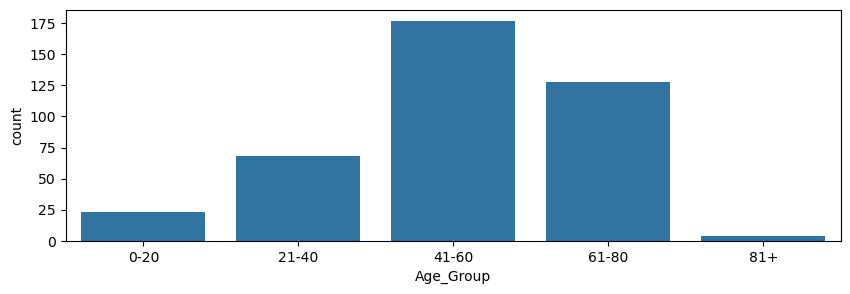

In [17]:
# Binning the age variable
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81+']

df_clean['Age_Group'] = pd.cut(
    df_clean['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(10,3))
sns.countplot(x=df_clean['Age_Group'])
plt.show()

### Comparison of Selected Features

The charts below compare the median values of five selected features for the CKD and non-CKD groups. These fields were selected because they appeared near the top of the Random Forest feature-importance results. The median is used because some laboratory fields contain unusually high values, thereby decreasing the impact of outliers.


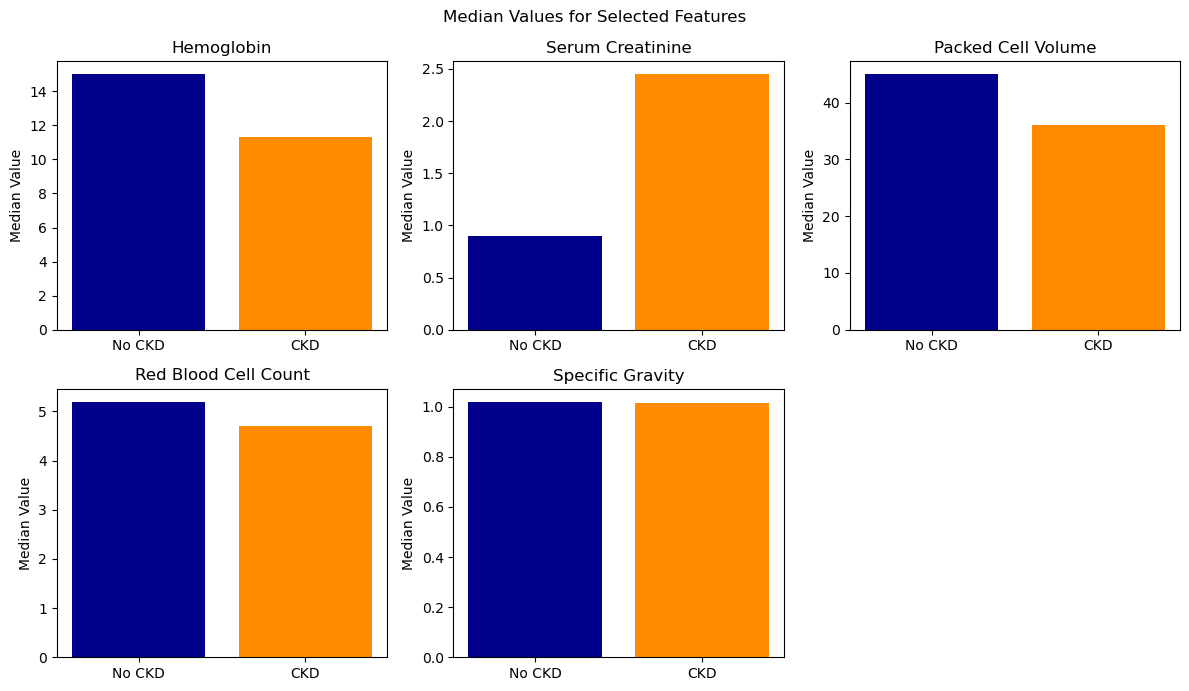

In [18]:
selected_features = ['hemo', 'sc', 'pcv', 'rc', 'sg']

feature_names = {
    'hemo': 'Hemoglobin',
    'sc': 'Serum Creatinine',
    'pcv': 'Packed Cell Volume',
    'rc': 'Red Blood Cell Count',
    'sg': 'Specific Gravity'
}

# Find the median for each CKD group
feature_medians = df_clean.groupby('CKD_class')[
    selected_features
].median()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    values = feature_medians[feature]

    axes[i].bar(
        ['No CKD', 'CKD'],
        values,
        color=['darkblue', 'darkorange']
    )

    axes[i].set_title(feature_names[feature])
    axes[i].set_ylabel('Median Value')

axes[5].axis('off')

plt.suptitle('Median Values for Selected Features')
plt.tight_layout()
plt.show()


Select features were cast into barcharts, ploting the differentiation of those diagnosed with CKD, versus No CKD diagnosis.  The charts provide a simple view of whether the variable is a contributing factor to diagnosing CKD.  A limitation is that the charts only show each factor alone, yet the factors in combination with other factors could present a different picture.


## Predictive Modeling

### Modeling Approach

The target for the analysis is the "CKD_class" field, where 1 means CKD and 0 means no CKD. The text field named "classification" mirrors the "CKD_class" field, and was eliminated as such. The "id" field was also dropped, to prevent this from entering into any model analytics.

Categorical fields were changed into 0/1 dummy variables, to facilitate the use of models that could not read in 'str' variable types. 

A new df_model dataframe was created, resulting from the excluded columns, and the transformation into the dummies columns.


In [19]:
# Prepare numeric predictors and the binary target
exclude_cols = ['id', 'classification', 'CKD_class']

categorical_cols = [
    col for col in df_clean.select_dtypes(
        include=['object', 'category', 'string']
    ).columns
    if col not in exclude_cols
]

df_model = pd.get_dummies(
    df_clean,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X = df_model.drop(columns=exclude_cols, errors='ignore')
y = df_model['CKD_class']

print('Target counts:')
print(y.value_counts().sort_index())
print('\nNon-numeric predictor columns:', X.select_dtypes(exclude='number').columns.tolist())


Target counts:
CKD_class
0    152
1    248
Name: count, dtype: int64

Non-numeric predictor columns: []


## Split Train and Test Data

Using sklearn the model data was split into training and testing segments. The decision was made to reserve 20% for testing. Further, the random_state was set, arbitrarily at 42, so that all analyses could use the same starting point and algorithm to group data. All models will be compared against the same training/testing data, for proper evaluation among models.  

The data selection was further "stratified" to include relatively the same proportion of CKD and No CKD classifications, controlling for similarity of classifications between training and testing.  

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set: ', X_test.shape)
print('\nTraining target proportions:')
print(y_train.value_counts(normalize=True).sort_index().round(4))
print('\nTesting target proportions:')
print(y_test.value_counts(normalize=True).sort_index().round(4))


Training set: (320, 28)
Testing set:  (80, 28)

Training target proportions:
CKD_class
0    0.3812
1    0.6188
Name: proportion, dtype: float64

Testing target proportions:
CKD_class
0    0.375
1    0.625
Name: proportion, dtype: float64


### Model Evaluation Measures

The following measures were incorporated to evaluate the performance of the model, when comparing the predicted values with the actual values for the test data.

- **Accuracy** shows how often the model was correct overall.
- **Precision** shows how often a CKD prediction was correct.
- **Recall** shows how many actual CKD cases the model found.
- **F1 score** balances precision and recall.
- **ROC-AUC** measures how well the model separates CKD from non-CKD across different cutoffs.

Recall is especially important in this project because a false negative is a CKD case that the model missed, so missing a diagnosis of someone who truly had CKD. Training and testing accuracy are also compared to check for overfitting. Training accuracy should logically be high, because the models are trained on this subset. However, if there is considerable discrepancy between the training and testing accuracy, this would indicate overfitting of the model to the training data, discrediting the model for general use in testing to some degree.  Ideally, these figures should be close, but also depend upon the data.


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


def model_metrics(name, model, X_train_data, X_test_data, y_train_data, y_test_data):
    predictions = model.predict(X_test_data)
    probabilities = model.predict_proba(X_test_data)[:, 1]

    result = {
        'Model': name,
        'Train Accuracy': model.score(X_train_data, y_train_data),
        'Test Accuracy': accuracy_score(y_test_data, predictions),
        'Precision': precision_score(y_test_data, predictions),
        'Recall': recall_score(y_test_data, predictions),
        'F1 Score': f1_score(y_test_data, predictions),
        'ROC-AUC': roc_auc_score(y_test_data, probabilities)
    }
    return result, predictions, probabilities


### Logistic Regression

Logistic Regression was used as the starting model. It estimates the probability that a patient belongs to the CKD class. The pipeline, a standard line in the model, fills any remaining missing values with the median and scales the predictors before fitting the model. Scaling is nis used due to the various ranges of the values in the fields, to eliminate the value distribution's effect in the model.

In [22]:
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_result, y_pred_logistic, y_prob_logistic = model_metrics(
    'Logistic Regression', logistic_model,
    X_train, X_test, y_train, y_test
)

pd.Series(logistic_result).to_frame('Result').round(4)


,Result
Model,Logistic Regression
Train Accuracy,0.996875
Test Accuracy,0.9875
Precision,0.980392
Recall,1.0
F1 Score,0.990099
ROC-AUC,0.977333


              precision    recall  f1-score   support

      No CKD       1.00      0.97      0.98        30
         CKD       0.98      1.00      0.99        50

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



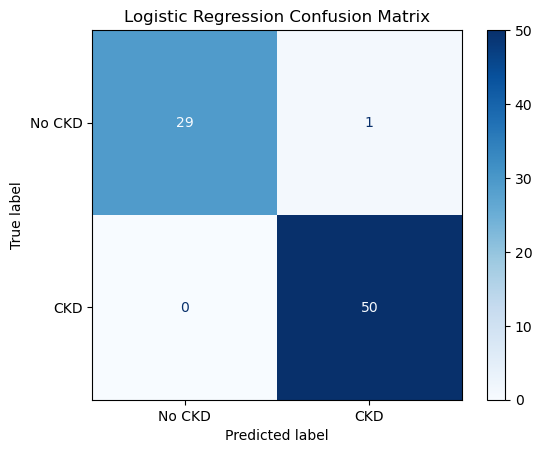

In [23]:
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['No CKD', 'CKD']
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=['No CKD', 'CKD'],
    cmap='Blues'
)
plt.title('Logistic Regression Confusion Matrix')
plt.show()


### Decision Tree - Baseline

The Decision Tree model was first run with no limits, to set a baseline. The model resulted in a depth of 6 and 12 leaves.


In [24]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_result, y_pred_dt, y_prob_dt = model_metrics(
    'Decision Tree - Baseline', dt_model,
    X_train, X_test, y_train, y_test
)

print('Tree depth:', dt_model.get_depth())
print('Number of leaves:', dt_model.get_n_leaves())
pd.Series(dt_result).to_frame('Result').round(4)


Tree depth: 6
Number of leaves: 12


,Result
Model,Decision Tree - Baseline
Train Accuracy,1.0
Test Accuracy,0.95
Precision,0.96
Recall,0.96
F1 Score,0.96
ROC-AUC,0.946667


### Decision Tree Tuning

GridSearchCV was used to test several tree depths, minimum split sizes, and minimum leaf sizes. It used five-fold cross-validation on the training data. Recall was selected as the scoring measure because identifying CKD cases was the main priority. The test data were not used to choose the settings.


In [25]:
dt_param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

dt_tuned = dt_grid.best_estimator_
dt_tuned_result, y_pred_dt_tuned, y_prob_dt_tuned = model_metrics(
    'Decision Tree - Tuned', dt_tuned,
    X_train, X_test, y_train, y_test
)

print('Best parameters:', dt_grid.best_params_)
print('Best cross-validation recall:', round(dt_grid.best_score_, 3))
print('Tree depth:', dt_tuned.get_depth())
print('Number of leaves:', dt_tuned.get_n_leaves())
pd.Series(dt_tuned_result).to_frame('Result').round(4)


Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation recall: 0.985
Tree depth: 3
Number of leaves: 7


,Result
Model,Decision Tree - Tuned
Train Accuracy,0.990625
Test Accuracy,0.95
Precision,0.96
Recall,0.96
F1 Score,0.96
ROC-AUC,0.948


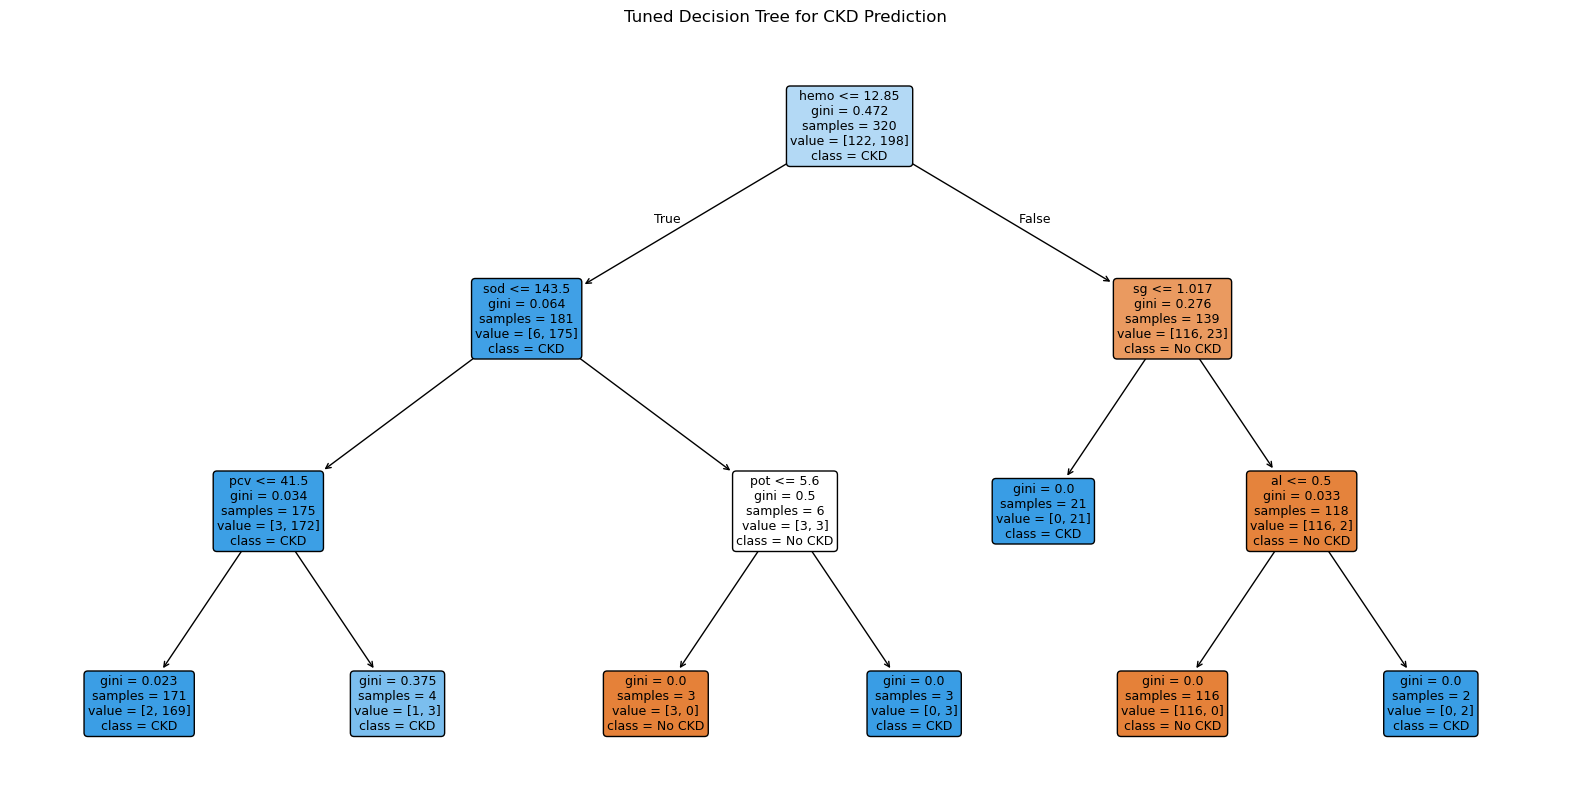

In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_tuned,
    feature_names=X_train.columns,
    class_names=['No CKD', 'CKD'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Tuned Decision Tree for CKD Prediction')
plt.show()

### Random Forest

Random Forest combines the results of many Decision Trees. The model used 100 trees and then combined their predictions. This usually produces a more stable result than relying on one tree. The model was first tested with standard settings before any tuning.


In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_result, y_pred_rf, y_prob_rf = model_metrics(
    'Random Forest', rf_model,
    X_train, X_test, y_train, y_test
)

pd.Series(rf_result).to_frame('Result').round(4)


,Result
Model,Random Forest
Train Accuracy,1.0
Test Accuracy,0.975
Precision,0.961538
Recall,1.0
F1 Score,0.980392
ROC-AUC,0.972333


## Random Forest Feature Analysis

The Random Forest model has a rf_importance function that shows how each factor contributed to the model. The top 10 Features are shown here. This analysis was key in further model refinement, in tuning the hyperparameters of other models as well.  

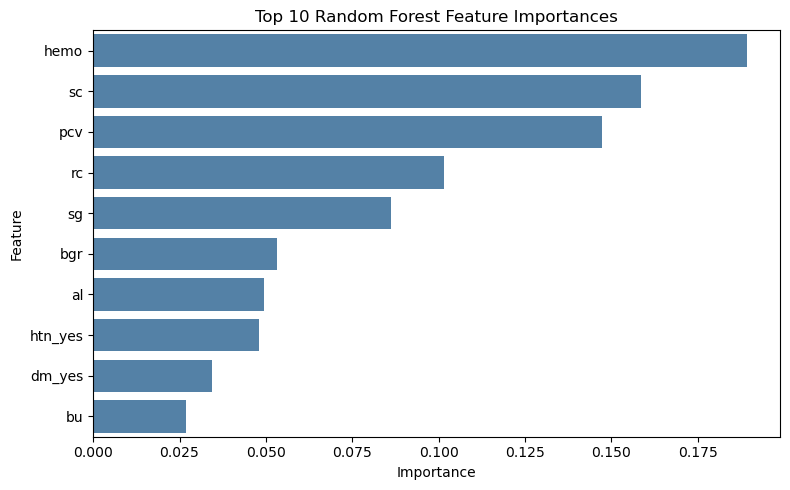

,Feature,Importance
10,hemo,0.1894
7,sc,0.1586
11,pcv,0.1474
13,rc,0.1016
2,sg,0.0861
5,bgr,0.0532
3,al,0.0494
18,htn_yes,0.0481
19,dm_yes,0.0344
6,bu,0.0269


In [28]:
rf_importance = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance, x='Importance', y='Feature', color='steelblue')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

rf_importance.round(4)


### Gradient Boosting

Gradient Boosting creates a series of small Decision Trees. Each new tree tries to improve mistakes made by the earlier trees. The model uses 100 trees, a learning rate of 0.05, and a maximum depth of 2. The shallow trees and small learning rate are intended to reduce overfitting.


In [29]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_result, y_pred_gb, y_prob_gb = model_metrics(
    'Gradient Boosting',
    gb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.Series(gb_result).to_frame('Result').round(4)


,Result
Model,Gradient Boosting
Train Accuracy,0.99375
Test Accuracy,0.975
Precision,0.98
Recall,0.98
F1 Score,0.98
ROC-AUC,0.974


### Gaussian Naive Bayes

Gaussian Naive Bayes calculates the probability that a record belongs to each class. It is simple, fast, and often works well with smaller datasets. It assumes the predictors are mostly independent. That assumption does not fully apply to this dataset because some blood measurements are correlated, but the model is still useful for comparison.

The Gaussian Naive Bayes model makes use of probability. It is based upon the bell-shaped curve, looks at the vales of the features in the model, and tries to predict based upon probability which test records are most similar to those that classify the dependent variable, CKD in this case.  


In [30]:
from sklearn.naive_bayes import GaussianNB

nb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', GaussianNB())
])

nb_model.fit(X_train, y_train)

nb_result, y_pred_nb, y_prob_nb = model_metrics(
    'Gaussian Naive Bayes',
    nb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.Series(nb_result).to_frame('Result').round(3)


,Result
Model,Gaussian Naive Bayes
Train Accuracy,0.9375
Test Accuracy,0.95
Precision,0.979167
Recall,0.94
F1 Score,0.959184
ROC-AUC,0.982


### Additional Model Confusion Matrices

These matrices show the correct and incorrect classifications for Gradient Boosting and Naive Bayes. The lower-left box is especially important because it contains CKD cases that the model predicted as non-CKD.


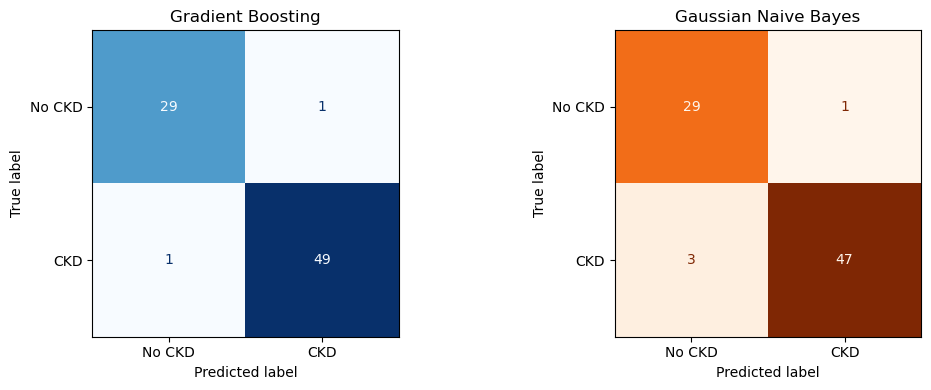

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    display_labels=['No CKD', 'CKD'],
    cmap='Blues',
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title('Gradient Boosting')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=['No CKD', 'CKD'],
    cmap='Oranges',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title('Gaussian Naive Bayes')

plt.tight_layout()
plt.show()


Gradient Boosting and Naive Bayes are evaluated with the same measures as the other models. Recall is reviewed first because it shows how many CKD cases were correctly identified. Accuracy, precision, F1, and ROC-AUC are also included in the final comparison table.


## Top 5 and Top 3 Indicator Models

The original models use all features. To explore whether all features were needed, a modified analysis was performed that included only Top 5 and Top 3 Features as noted in the Random Forest analysis.

Two groups were tested:

Top_5 features: hemoglobin, serum creatinine, packed cell volume, red blood cell count, and specific gravity.

Top_3 features: hemoglobin, serum creatinine, and packed cell volume.




In [32]:
# Select smaller groups of predictors
Top_5 = ['hemo', 'sc', 'pcv', 'rc', 'sg']
Top_3 = ['hemo', 'sc', 'pcv']

X_train_5 = X_train[Top_5]
X_test_5 = X_test[Top_5]

X_train_3 = X_train[Top_3]
X_test_3 = X_test[Top_3]

print('Top_5 model:', Top_5)
print('Top_3 model:', Top_3)


Top_5 model: ['hemo', 'sc', 'pcv', 'rc', 'sg']
Top_3 model: ['hemo', 'sc', 'pcv']


### Reduced Logistic Regression Models

The same Logistic Regression pipeline is fitted with Top 5 features and then Top 3. Median imputation and scaling are still included so the only major difference is the number of predictors.


In [33]:
def create_logistic_model():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])


logistic_5 = create_logistic_model()
logistic_5.fit(X_train_5, y_train)
logistic_5_result, y_pred_logistic_5, y_prob_logistic_5 = model_metrics(
    'Logistic Regression - Top 5',
    logistic_5,
    X_train_5,
    X_test_5,
    y_train,
    y_test
)

logistic_3 = create_logistic_model()
logistic_3.fit(X_train_3, y_train)
logistic_3_result, y_pred_logistic_3, y_prob_logistic_3 = model_metrics(
    'Logistic Regression - Top 3',
    logistic_3,
    X_train_3,
    X_test_3,
    y_train,
    y_test
)

pd.DataFrame([
    logistic_result,
    logistic_5_result,
    logistic_3_result
]).round(4)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9969,0.9875,0.9804,1.00,0.9901,0.9773
1,Logistic Regression - Top 5,0.9531,0.9625,0.9608,0.98,0.9703,0.9767
2,Logistic Regression - Top 3,0.9312,0.9625,0.9608,0.98,0.9703,0.9813


### Top 5 and Top 3 Random Forest Models

The Random Forest is also refitted with the same five-feature and three-feature groups. Each version still uses 100 trees and the same random seed.


In [34]:
rf_5 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_5.fit(X_train_5, y_train)
rf_5_result, y_pred_rf_5, y_prob_rf_5 = model_metrics(
    'Random Forest - Top 5',
    rf_5,
    X_train_5,
    X_test_5,
    y_train,
    y_test
)

rf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_3.fit(X_train_3, y_train)
rf_3_result, y_pred_rf_3, y_prob_rf_3 = model_metrics(
    'Random Forest - Top 3',
    rf_3,
    X_train_3,
    X_test_3,
    y_train,
    y_test
)

pd.DataFrame([
    rf_result,
    rf_5_result,
    rf_3_result
]).round(4)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,1.0000,0.9750,0.9615,1.00,0.9804,0.9723
1,Random Forest - Top 5,1.0000,0.9625,0.9608,0.98,0.9703,0.9727
2,Random Forest - Top 3,0.9875,0.9625,0.9608,0.98,0.9703,0.9697


## Top 5/Top 3 - Model Comparison

The chart focuses on test accuracy and CKD recall. Recall should receive the most attention because it shows whether the smaller models continue to find the actual CKD cases.

Recall answers this question:
Of all the patients who actually had CKD, what percentage did the model correctly identify?

Accuracy answers:
Of all the patients in the test data, what percentage did the model classify correctly?
​	
 



In [35]:
reduced_results = pd.DataFrame([
    logistic_result,
    logistic_5_result,
    logistic_3_result,
    rf_result,
    rf_5_result,
    rf_3_result
])

display(reduced_results.round(4))



,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9969,0.9875,0.9804,1.00,0.9901,0.9773
1,Logistic Regression - Top 5,0.9531,0.9625,0.9608,0.98,0.9703,0.9767
2,Logistic Regression - Top 3,0.9312,0.9625,0.9608,0.98,0.9703,0.9813
3,Random Forest,1.0000,0.9750,0.9615,1.00,0.9804,0.9723
4,Random Forest - Top 5,1.0000,0.9625,0.9608,0.98,0.9703,0.9727
5,Random Forest - Top 3,0.9875,0.9625,0.9608,0.98,0.9703,0.9697


## Model Comparison - All Models

Each row in the comparison table is calculated from predictions on the same 80-observation test set. Training accuracy is included to show the size of the generalization gap, while precision, recall, F1, and ROC-AUC provide a more complete view of classification performance.


In [37]:
results = pd.DataFrame([
    logistic_result,
    logistic_5_result,
    logistic_3_result,
    dt_result,
    dt_tuned_result,
    rf_result,
    gb_result,
    nb_result,
    rf_5_result,
    rf_3_result
])

results = results[
    ['Model', 'Train Accuracy', 'Test Accuracy',
     'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
]

results.round(4)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9969,0.9875,0.9804,1.00,0.9901,0.9773
1,Logistic Regression - Top 5,0.9531,0.9625,0.9608,0.98,0.9703,0.9767
2,Logistic Regression - Top 3,0.9312,0.9625,0.9608,0.98,0.9703,0.9813
3,Decision Tree - Baseline,1.0000,0.9500,0.9600,0.96,0.9600,0.9467
4,Decision Tree - Tuned,0.9906,0.9500,0.9600,0.96,0.9600,0.9480
5,Random Forest,1.0000,0.9750,0.9615,1.00,0.9804,0.9723
6,Gradient Boosting,0.9938,0.9750,0.9800,0.98,0.9800,0.9740
7,Gaussian Naive Bayes,0.9375,0.9500,0.9792,0.94,0.9592,0.9820
8,Random Forest - Top 5,1.0000,0.9625,0.9608,0.98,0.9703,0.9727
9,Random Forest - Top 3,0.9875,0.9625,0.9608,0.98,0.9703,0.9697


Note:  Feature engineering was tested, but the resulting models did not positively affect the performance.  Therefore, the Feature engineering models were dropped from the report.

## Summary:   